In [1]:
import json
import os
from pathlib import Path
import sys

# Add the repo folder for imports
dirpath_repo_root = Path().resolve().parents[2]
sys.path.append(str(dirpath_repo_root))
print(f'Repo root: {dirpath_repo_root}')

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline
import xarray as xr

Repo root: /ddn/niknovikov19/repo/A1_OUinp


In [2]:
exp_name = 'exp_all_wxe_0_1_wxi_0_6_xisi_t_1.0_20.0_xsec_soma_soma'

dirpath_res = (dirpath_repo_root / 'exp_results' /              
               'single_unconn' / 'psp_tuning' / exp_name)

# Read config
with open(dirpath_res / 'psp_tuning_cfg.json', 'r') as fid:
    cfg = json.load(fid)['simConfig']

pops = cfg['pops_active']
psp_par = cfg['psp_inp_params']

In [3]:
tmin, tmax = psp_par['t_interval']
t0_xe = tmin + psp_par['t0_xe']
t0_xi = tmin + psp_par['t0_xi']
T = psp_par['xisi']

tx0 = {'xe': psp_par['t0_xe'],
       'xi': psp_par['t0_xi']}
wx_range = {'xe': psp_par['wxe_range'],
            'xi': psp_par['wxi_range']}

t_bl = (500, 1000)   # baseline
t_win = (-10, 100)   # PSP window around spike

In [9]:
V_all = {}
for pop in pops:
    V = xr.load_dataarray(dirpath_res / 'voltages' / f'{pop}.nc')
    V_all[pop] = V.isel(cell_gid=0)

In [11]:
def extract_psp(pop, xtype):
    V = V_all[pop]

    # Baseline
    v0 = V.sel(time=slice(t_bl[0], t_bl[1]))
    v0 = v0.mean().item()

    tx0_ = tx0[xtype]
    ts = np.arange(tmin + tx0_, tmax + tx0_, T)
    ts = ts[ts < (tmax - t_win[1])]

    wmin, wmax = wx_range[xtype]

    wx = []
    psp = []
    for ts_ in ts:
        # Input weight
        wx_ = wmin + (wmax - wmin) * (ts_ - tmin) / (tmax - tmin)
        wx.append(wx_)
        # PSP
        v = V.sel(time=slice(ts_ + t_win[0], ts_ + t_win[1]))
        psp_ = np.abs(v - v0).max().item()
        psp.append(psp_)
    wx = np.asarray(wx)
    psp = np.asarray(psp)# * 1000
    return wx, psp

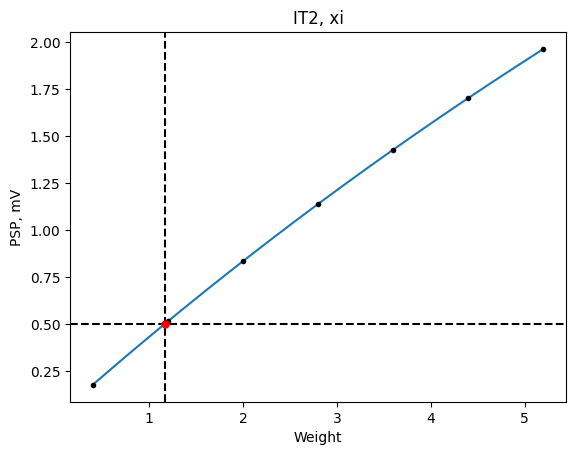

In [14]:
#pops_used = pops
#pops_used = [pops[0]]
pops_used = ['IT2']

xtypes_used = ['xi']

psp_target = {'xe': 0.5, 'xi': 0.5}
epsp, ipsp = psp_target['xe'], psp_target['xi']
wx_target = {pop: {} for pop in pops_used}

dirname_figs = f'wx_psp_figs_epsp_{epsp}_ipsp_{ipsp}'
dirpath_figs = dirpath_res / dirname_figs
os.makedirs(dirpath_figs, exist_ok=True)

for pop in pops_used:
    for xtype in xtypes_used:

        # Extract PSPs and corresponding weights from voltage data
        wx, psp = extract_psp(pop, xtype)

        # Cubic interpolator: PSP -> weight
        try:
            interp = CubicSpline(psp, wx)
        except:
            print(f'Error: Could not create interpolator for {pop}, {xtype}. Skipping.')
            wx_target[pop][xtype] = None
            interp = None

        if interp is not None:
            # Fing the weight that yields the required PSP value
            psp0 = psp_target[xtype]
            wx0 = interp(psp0).item()
            wx_target[pop][xtype] = wx0

            # Interpolated dense (wx, psp) for visualization
            psp_dense = np.linspace(psp.min(), psp.max(), 200)
            wx_dense = interp(psp_dense)

        # Visualize
        plt.figure(111); plt.clf()
        if interp is not None:
            plt.axhline(y=psp0, color='k', linestyle='--')
            plt.axvline(wx0, color='k', linestyle='--')
            plt.plot(wx_dense, psp_dense)
        plt.plot(wx, psp, 'k.')
        if interp is not None:
            plt.plot(wx0, psp0, 'r.', markersize=10)
        plt.xlabel('Weight')
        plt.ylabel('PSP, mV')
        plt.title(f'{pop}, {xtype}')
        #plt.show()
        plt.savefig(dirpath_figs / f'{pop}_{xtype}.png')

# Save results to json
res = {
    't_baseline': t_bl,
    'psp_target': psp_target,
    'wx_target': wx_target
}
fname_out = f'wx_target_epsp_{epsp}_ipsp_{ipsp}.json'
with open(dirpath_res / fname_out, 'w') as fid:
    json.dump(res, fid, indent=4)

In [60]:
wx, np.round(psp, 1)

(array([0.4, 1.2, 2. , 2.8, 3.6, 4.4, 5.2, 6. ]),
 array([0.1, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 0. ]))

ValueError: x and y must have same first dimension, but have shapes (111,) and (1, 111)

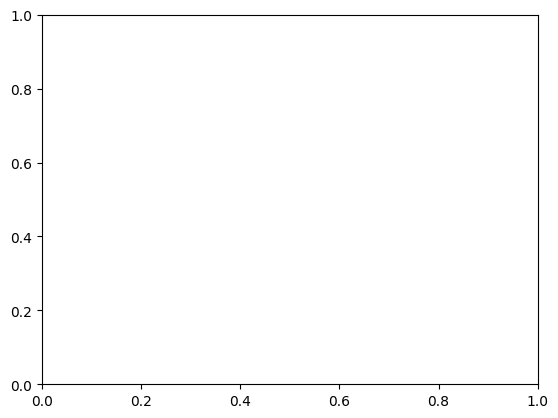

In [56]:
t_win = (-10, 100)

tx0_ = tx0['xi']
ts = np.arange(tmin + tx0_, tmax + tx0_, T)

plt.figure()
for ts_ in ts:
    v = V.sel(time=slice(ts_ + t_win[0], ts_ + t_win[1]))
    plt.plot(v.time - ts_, v)
plt.xlabel('Time')
plt.title(f'Voltage, {pop}')